In [ ]:
try:
    # se estiver no colab vai rodar o bloco abaixo
    from google.colab import data_table, files
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    path = "." # caminho do google drive
except:
    # se nao estiver no colab vai rodar o bloco abaixo
    path = "." # caminho local


Mounted at /content/drive


In [ ]:
import os
import glob
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def rmse_calc(x, y):
    """
    Calculates the Root Mean Square Error (RMSE).

    Args:
        x (array-like): Array of actual values.
        y (array-like): Array of predicted values.

    Returns:
        float: The calculated RMSE value.
    """
    return np.sqrt(np.mean((x - y)**2))


def get_stats(target, prediction):
    n = target.size
    print("N: ", n)
    abs_error = prediction - target
    mbe = np.nanmean(abs_error) # mean bias error
    se = np.square(abs_error) # squared errors
    mse = np.nanmean(se) # mean squared errors
    rmse = np.sqrt(mse) # Root Mean Squared Error, RMSE
    rho, p = stats.pearsonr(target, prediction)
    # rho = xr.corr(prediction, target).values
    return f"""$N = {n}$
$ρ = {rho:.2f}$
$MBE = {mbe:.2f}$
$RMSE = {rmse:.2f}$"""



In [ ]:
ta100_files = glob.glob(path + "/TA100/*/*_DADO10min_*.dat", recursive=True)
sodar_files = glob.glob(path + "/SODAR/*/*.txt", recursive=True)


In [ ]:
def ta100_load(f):
    df = pd.read_csv(f, sep=',', header=0, skiprows=[0, 2, 3], engine='python', quotechar='"',na_values=["NAN"])
    df.set_index('TIMESTAMP', inplace=True)
    cols = ["VentoVel10_WVc(1)", "VentoVel20_WVc(1)", "VentoVel30_WVc(1)", "VentoVel40_WVc(1)", "VentoVel50_WVc(1)", "VentoVel60_WVc(1)", "VentoVel70_WVc(1)", "VentoVel80_WVc(1)", "VentoVel90_WVc(1)", "VentoVel100_WVc(1)"]
    df = df[cols]
    df.index = pd.to_datetime(df.index)
    df = df.resample("30min").mean()
    df.columns = ['10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
    # print(df.shape)
    return df

# Load and concatenate dataframes from SODAR_TA100 files
ta100 = []
for f in ta100_files:
    df = ta100_load(f)
    ta100.append(df)

# Concatenate all dataframes into a single dataframe
ta100 = pd.concat(ta100)
ta100.tail()
print(ta100.shape)

(12981, 10)


In [ ]:
def sodar_load(f):
    df = pd.read_csv(f, sep='\t', header=[0,1], skiprows=[0, 1, 2, 3, 4, 7], engine='python', quotechar='"', na_values=["*"])
    df.columns = [" ".join(x) for x in df.columns]
    df.rename(columns={"- -": "TIMESTAMP"}, inplace=True)
    df.set_index('TIMESTAMP', inplace=True)
    df.index = pd.to_datetime(df.index)
    # print(df.columns)
    cols = ['10 speed', '20 speed', '30 speed', '40 speed', '50 speed', '60 speed', '70 speed', '80 speed', '90 speed', '100 speed']
    df = df[cols]
    df.columns = ['10', '20', '30', '40', '50', '60', '70', '80', '90', '100']
    return df

# Load and concatenate dataframes from SODAR_sodar files
sodar = []
for f in sodar_files: #[50:55]:
    df = sodar_load(f)
    sodar.append(df)

# Concatenate all dataframes into a single dataframe
sodar = pd.concat(sodar)
print(sodar.shape)
sodar.head()

(11075, 10)


,10,20,30,40,50,60,70,80,90,100
TIMESTAMP,,,,,,,,,,
2023-01-24 09:30:00,NaN,1.46,2.58,3.58,3.66,3.82,4.13,4.18,3.93,3.79
2023-01-24 10:00:00,NaN,3.52,4.11,4.45,4.19,4.72,4.94,6.16,4.57,5.29
2023-01-24 10:30:00,1.12,4.61,5.85,6.27,6.43,5.91,6.17,5.94,5.31,5.37
2023-01-24 11:00:00,NaN,4.32,5.86,6.63,6.57,6.42,6.81,7.45,7.13,6.86
2023-01-24 11:30:00,NaN,7.17,6.92,7.27,7.56,7.63,7.20,7.57,8.28,7.86


Index(['10', '20', '30', '40', '50', '60', '70', '80', '90', '100'], dtype='object')
Level: 10
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8500, 2)
N:  1108
$N = 1108$
$ρ = 0.31$
$MBE = -0.41$
$RMSE = 1.79$


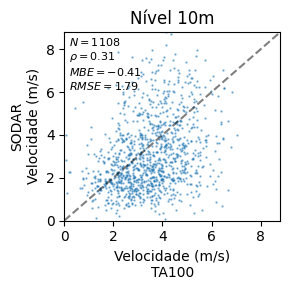

Level: 20
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8570, 2)
N:  4944
$N = 4944$
$ρ = 0.64$
$MBE = -1.43$
$RMSE = 2.05$


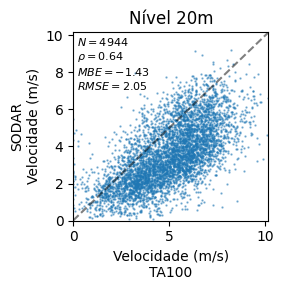

Level: 30
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8556, 2)
N:  4975
$N = 4975$
$ρ = 0.66$
$MBE = -1.62$
$RMSE = 2.17$


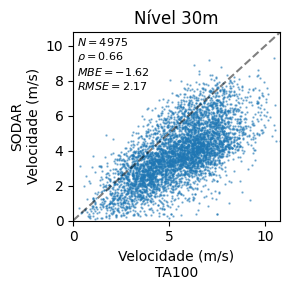

Level: 40
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8540, 2)
N:  4958
$N = 4958$
$ρ = 0.64$
$MBE = -1.44$
$RMSE = 2.18$


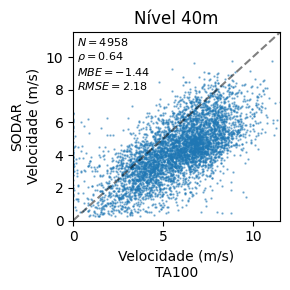

Level: 50
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8477, 2)
N:  4882
$N = 4882$
$ρ = 0.67$
$MBE = -1.25$
$RMSE = 1.99$


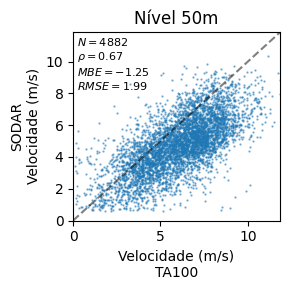

Level: 60
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8495, 2)
N:  4869
$N = 4869$
$ρ = 0.69$
$MBE = -1.30$
$RMSE = 1.99$


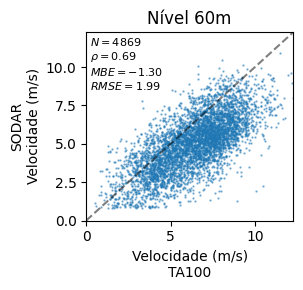

Level: 70
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8445, 2)
N:  4837
$N = 4837$
$ρ = 0.69$
$MBE = -1.33$
$RMSE = 2.02$


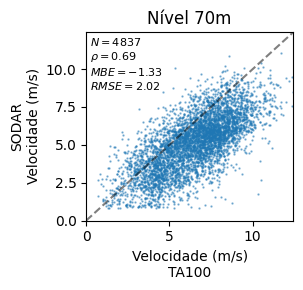

Level: 80
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8448, 2)
N:  4815
$N = 4815$
$ρ = 0.70$
$MBE = -1.26$
$RMSE = 1.98$


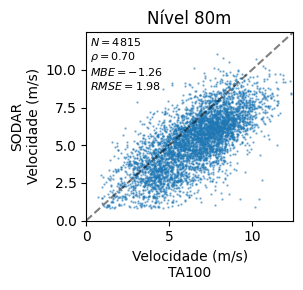

Level: 90
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8440, 2)
N:  4752
$N = 4752$
$ρ = 0.71$
$MBE = -1.17$
$RMSE = 1.90$


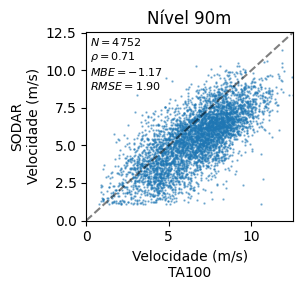

Level: 100
DataFrame Original: (8597, 2)
DataFrame No-Outliers: (8406, 2)
N:  4649
$N = 4649$
$ρ = 0.71$
$MBE = -1.23$
$RMSE = 1.98$


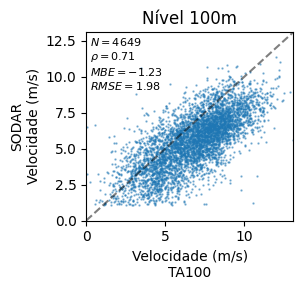

In [ ]:
print(sodar.columns)

for l in sodar.columns:
    print(f"Level: {l}")

    merged = pd.merge(sodar[f'{l}'], ta100[f'{l}'], left_index=True, right_index=True, suffixes=('_sodar', '_ta100'))

    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = merged.quantile(0.25)
    Q3 = merged.quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define bounds for outlier detection using 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("DataFrame Original:", merged.shape)

    # Filter the DataFrame to remove outliers
    # Keep only the rows where values are within the calculated bounds
    merged = merged[~((merged < lower_bound) | (merged > upper_bound)).any(axis=1)]

    print("DataFrame No-Outliers:", merged.shape)

    merged = merged.dropna()
    merged

    mmax = merged.values.max()

    stat = get_stats(merged[f'{l}_ta100'], merged[f'{l}_sodar'])

    print(stat)

    plt.figure(figsize=(3, 3))
    ax = plt.gca()

    plt.scatter(merged[f'{l}_ta100'], merged[f'{l}_sodar'], s=2, marker=".", alpha=0.5)
    plt.axline((0, 0), (mmax, mmax), color="black", ls='--', alpha=0.5)
    plt.title(f"Nível {l}m")
    plt.ylabel(f"SODAR\nVelocidade (m/s)")
    plt.xlabel(f"Velocidade (m/s)\nTA100")
    plt.xlim(0, mmax)
    plt.ylim(0, mmax)

    plt.text(0.02, 0.98, stat, fontsize=8, va='top', ha='left', transform = ax.transAxes)
    plt.tight_layout()
    # plt.grid(True)
    plt.savefig(f'{int(l):03}m.png')
    plt.show()
